# Pemanfaatan Data Mining dengan Aturan Asosiasi untuk Pengembangan Strategi Cross-Selling dan Bundling Produk Kosmetik

INFORMASI DATA
Jumlah transaksi: 3000
Kolom yang tersedia: ['Transaction', 'Products']

4 Transaksi Pertama (Head):
  1. ['Sunscreen', 'Serum Vitamin C']
  2. ['Face Wash']
  3. ['Moisturizer']
  4. ['Toner', 'Serum Vitamin C']

4 Transaksi Terakhir (Tail):
  2997. ['Face Wash']
  2998. ['Serum Vitamin C']
  2999. ['Sunscreen', 'Serum Vitamin C']
  3000. ['Serum Vitamin C']

STATISTIK PRODUK
Total transaksi: 3000
Jumlah produk unik: 5
Total pembelian produk: 6489
Rata-rata produk per transaksi: 2.16

Frekuensi kemunculan produk:
Produk | Jumlah Transaksi | Support
--------------------------------------------------
  Serum Vitamin C | 1879 | 0.6263 (62.63%)
  Face Wash | 1612 | 0.5373 (53.73%)
  Sunscreen | 1335 | 0.4450 (44.50%)
  Moisturizer | 981 | 0.3270 (32.70%)
  Toner | 682 | 0.2273 (22.73%)

TRANSFORMASI DATA
Dimensi data setelah transformasi: (3000, 5)
5 baris pertama data biner:
   Face Wash  Moisturizer  Serum Vitamin C  Sunscreen  Toner
0      False        False             

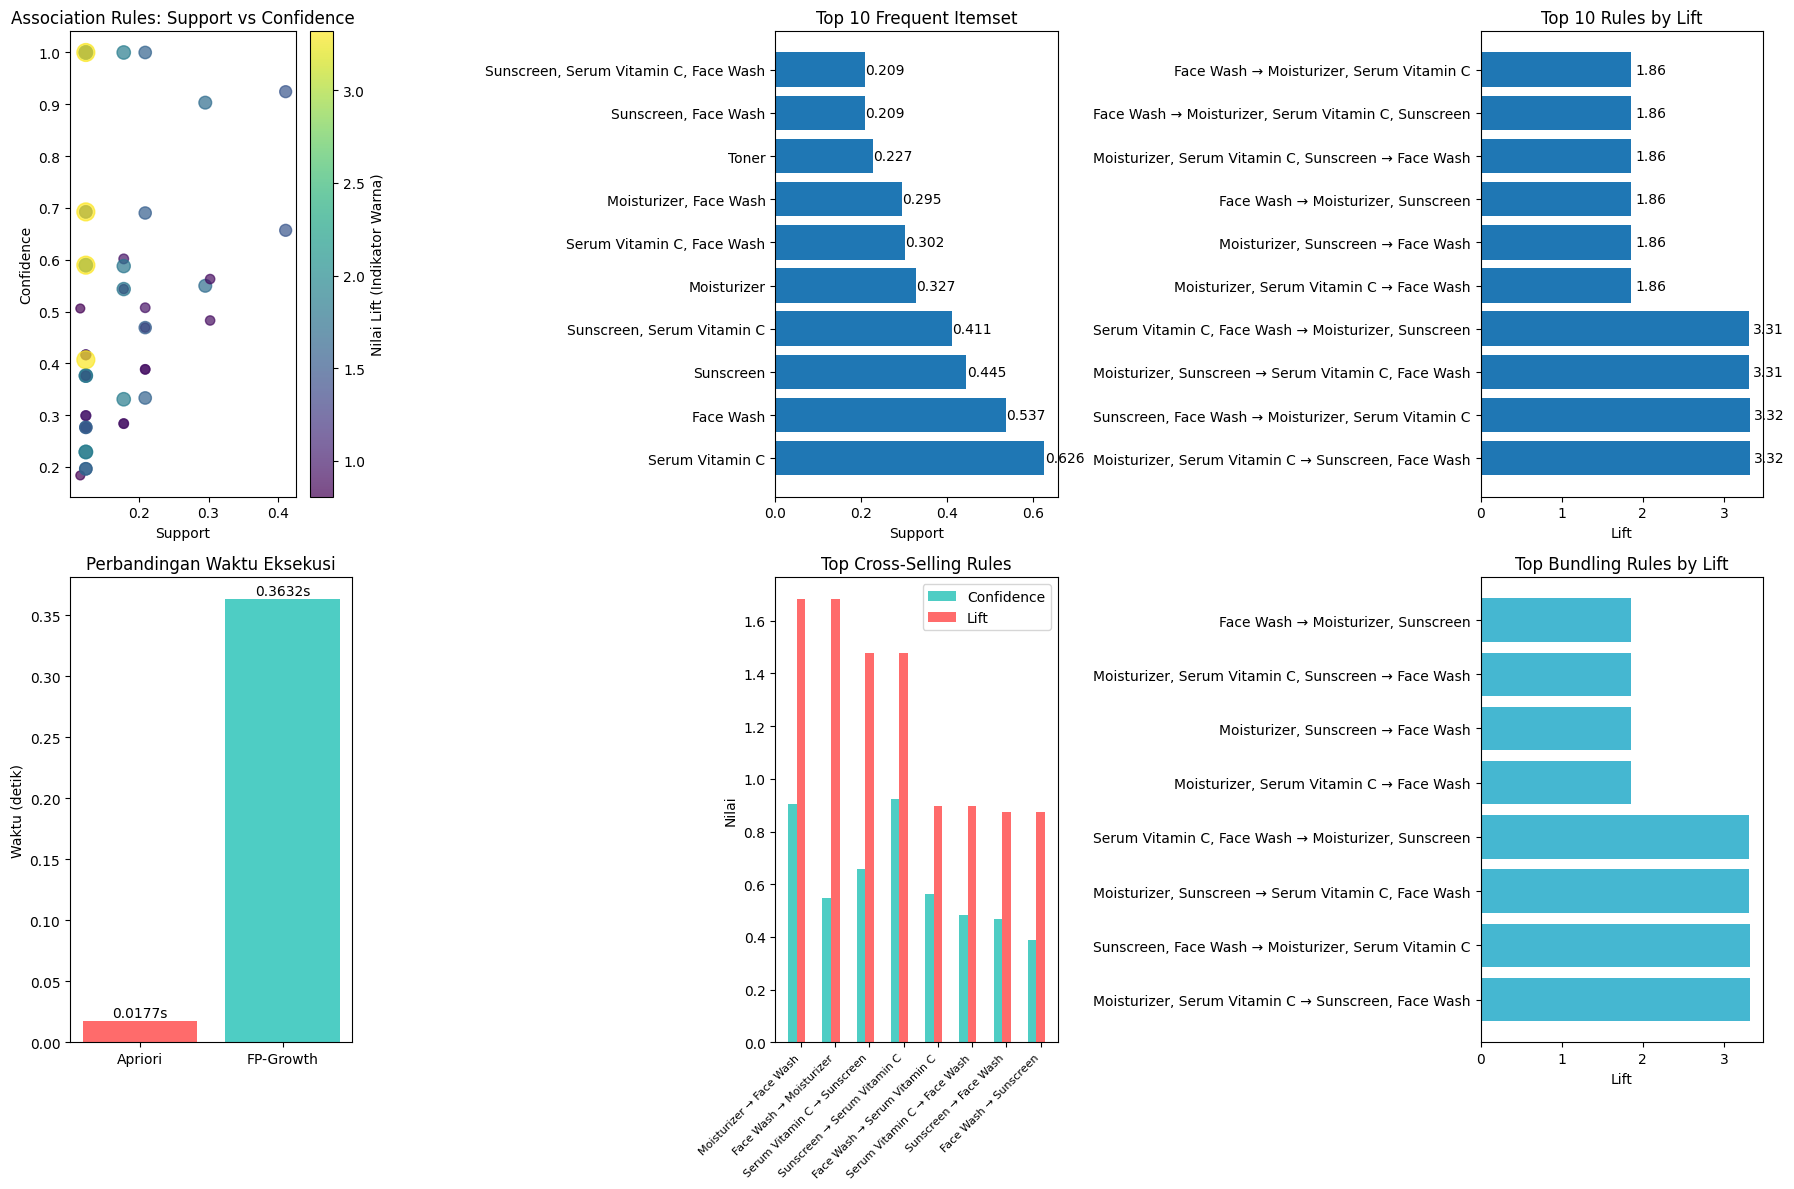


Visualisasi disimpan sebagai 'association_rules_analysis.png'

EKSPOR HASIL
Hasil disimpan ke file:
  - frequent_itemsets_apriori.csv (Support, itemsets)
  - association_rules.csv (Support, Confidence, Lift, dll)
  - cross_selling_rules.csv (Support, Confidence, Lift)
  - bundling_rules.csv (Confidence, Lift)
  - lift_verification.csv (Verifikasi perhitungan lift)

SUMMARY HASIL ANALISIS LENGKAP

1. DATA:
   - Total transaksi: 3000
   - Produk unik: 5 produk
   - Produk paling sering muncul: Serum Vitamin C
     (1879 transaksi, 62.63%)

2. FREQUENT ITEMSET (Tabel 2):
   - Kombinasi teratas: {Serum Vitamin C}
   - Support: 0.626333 (62.63%)

3. ALGORITMA:
   - Apriori: 0.0177 detik, 17 frequent itemset
   - FP-Growth: 0.3632 detik, 17 frequent itemset
   - Apriori lebih cepat 20.49x

4. ATURAN ASOSIASI:
   - Total aturan: 52
   - Aturan cross-selling: 14
   - Aturan bundling: 38

5. CROSS-SELLING (Tabel 3):

   - Aturan teratas: Moisturizer → Face Wash
     Support: 0.295333, Confiden

In [ ]:
# =============================================================================
# ANALISIS ASSOCIATION RULE MINING UNTUK STRATEGI CROSS-SELLING DAN BUNDLING
# PRODUK KOSMETIK
# =============================================================================
# Penulis: Nabila Zakiyah Zahra, Renta Siahaan, Tessa Kania Sagala,
#          M. Syamsuddin Wisnubroto, Fajri Farid
# Program Studi Sains Data, Institut Teknologi Sumatera
# =============================================================================

import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import time
import ast
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. MEMBACA DAN MEMPROSES DATA
# =============================================================================

# Baca file Excel
file_path = '/content/kosmetik_transactions (1).xlsx'
df = pd.read_excel(file_path)

print("=" * 80)
print("INFORMASI DATA")
print("=" * 80)
print(f"Jumlah transaksi: {len(df)}")
print(f"Kolom yang tersedia: {df.columns.tolist()}")

# Konversi kolom Products dari string ke list
def parse_products(val):
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    return val if isinstance(val, list) else []

df['Products'] = df['Products'].apply(parse_products)

# Ambil daftar transaksi
transactions = df['Products'].tolist()

# Tampilkan 4 transaksi pertama (head)
print("\n4 Transaksi Pertama (Head):")
for i, trans in enumerate(transactions[:4], 1):
    print(f"  {i}. {trans}")

# Tampilkan 4 transaksi terakhir (tail)
print("\n4 Transaksi Terakhir (Tail):")
for i, trans in enumerate(transactions[-4:], 1):
    print(f"  {len(transactions) - 4 + i}. {trans}")

# =============================================================================
# 2. STATISTIK DESKRIPTIF DATA
# =============================================================================

# Hitung frekuensi masing-masing produk
from collections import Counter

all_products = []
for trans in transactions:
    all_products.extend(trans)

product_counts = Counter(all_products)
total_transactions = len(transactions)

print("\n" + "=" * 80)
print("STATISTIK PRODUK")
print("=" * 80)
print(f"Total transaksi: {total_transactions}")
print(f"Jumlah produk unik: {len(product_counts)}")
print(f"Total pembelian produk: {sum(product_counts.values())}")
print(f"Rata-rata produk per transaksi: {sum(product_counts.values())/total_transactions:.2f}")

print("\nFrekuensi kemunculan produk:")
print("Produk | Jumlah Transaksi | Support")
print("-" * 50)
for product, count in sorted(product_counts.items(), key=lambda x: x[1], reverse=True):
    support = count / total_transactions
    print(f"  {product} | {count} | {support:.4f} ({support*100:.2f}%)")

# =============================================================================
# 3. PREPROCESSING: TRANSFORMASI DATA KE FORMAT BINER
# =============================================================================

print("\n" + "=" * 80)
print("TRANSFORMASI DATA")
print("=" * 80)

# Transformasi ke format biner
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Dimensi data setelah transformasi: {df_encoded.shape}")
print("5 baris pertama data biner:")
print(df_encoded.head())

# =============================================================================
# 4. PARAMETER ANALISIS
# =============================================================================

min_support = 0.1
min_confidence = 0.0

print("\n" + "=" * 80)
print("PARAMETER ANALISIS")
print("=" * 80)
print(f"Minimum Support: {min_support}")
print(f"Minimum Confidence: {min_confidence}")

# =============================================================================
# 5. FREQUENT ITEMSET DENGAN APRIORI
# =============================================================================

print("\n" + "=" * 80)
print("ALGORITMA APRIORI")
print("=" * 80)

start_time = time.time()
frequent_itemsets_apriori = apriori(df_encoded, min_support=min_support, use_colnames=True)
apriori_time = time.time() - start_time

print(f"\nWaktu eksekusi Apriori: {apriori_time:.4f} detik")
print(f"Jumlah frequent itemset: {len(frequent_itemsets_apriori)}")

# Tampilkan frequent itemset (Tabel 2 di artikel)
print("\n" + "=" * 80)
print("TABEL 2: FREQUENT ITEMSET APRIORI (SEMUA ITEMSET)")
print("=" * 80)
print("Itemset | Support | Support (%)")
print("-" * 70)

freq_sorted_apriori = frequent_itemsets_apriori.sort_values('support', ascending=False)
for idx, row in freq_sorted_apriori.iterrows():
    # Tampilkan semua itemset
    items = ', '.join(list(row['itemsets']))
    print(f"  {items} | {row['support']:.6f} | {row['support']*100:.2f}%")

# =============================================================================
# 6. FREQUENT ITEMSET DENGAN FP-GROWTH
# =============================================================================

print("\n" + "=" * 80)
print("ALGORITMA FP-GROWTH")
print("=" * 80)

start_time = time.time()
frequent_itemsets_fpgrowth = fpgrowth(df_encoded, min_support=min_support, use_colnames=True)
fpgrowth_time = time.time() - start_time

print(f"\nWaktu eksekusi FP-Growth: {fpgrowth_time:.4f} detik")
print(f"Jumlah frequent itemset: {len(frequent_itemsets_fpgrowth)}")

# Tampilkan frequent itemset FP-Growth yang difilter
print("\n" + "=" * 80)
print("FREQUENT ITEMSET FP-GROWTH (SEMUA ITEMSET)")
print("=" * 80)
print("Itemset | Support | Support (%)")
print("-" * 70)

freq_sorted_fpgrowth = frequent_itemsets_fpgrowth.sort_values('support', ascending=False)
for idx, row in freq_sorted_fpgrowth.iterrows():
    # Tampilkan semua itemset
    items = ', '.join(list(row['itemsets']))
    print(f"  {items} | {row['support']:.6f} | {row['support']*100:.2f}%")


# =============================================================================
# 7. PERBANDINGAN EFISIENSI APRIORI vs FP-GROWTH
# =============================================================================

print("\n" + "=" * 80)
print("PERBANDINGAN EFISIENSI APRIORI vs FP-GROWTH")
print("=" * 80)
print(f"Apriori    : {apriori_time:.4f} detik")
print(f"FP-Growth  : {fpgrowth_time:.4f} detik")
if apriori_time < fpgrowth_time:
    print(f"Selisih    : {fpgrowth_time - apriori_time:.4f} detik")
    print(f"Apriori lebih cepat {fpgrowth_time/apriori_time:.2f}x")
elif fpgrowth_time < apriori_time:
    print(f"Selisih    : {apriori_time - fpgrowth_time:.4f} detik")
    print(f"FP-Growth lebih cepat {apriori_time/fpgrowth_time:.2f}x")
else:
    print("Kedua algoritma memiliki waktu eksekusi yang hampir sama.")

# =============================================================================
# 8. PEMBENTUKAN ATURAN ASOSIASI
# =============================================================================

print("\n" + "=" * 80)
print("ATURAN ASOSIASI")
print("=" * 80)

# Gunakan frequent itemset dari Apriori untuk membentuk aturan
rules = association_rules(frequent_itemsets_apriori, metric="confidence", min_threshold=0.0)

print(f"Jumlah aturan yang terbentuk: {len(rules)}")
print(f"\nParameter evaluasi:")
print(f"  Minimum Support: {min_support}")
print(f"  Minimum Confidence: {min_confidence}")

# =============================================================================
# 9. TABEL 3: HASIL CROSS-SELLING
# =============================================================================

print("\n" + "=" * 80)
print("TABEL 3: HASIL CROSS-SELLING")
print("=" * 80)

# Filter aturan untuk cross-selling (aturan dengan 1 antecedent dan 1 consequent)
cross_selling_rules = rules[(rules['antecedents'].apply(len) == 1) &
                           (rules['consequents'].apply(len) == 1)]

cross_selling_rules = cross_selling_rules.sort_values(['lift', 'confidence'], ascending=[False, False])

# Hitung support untuk masing-masing produk
product_support = {}
for product in product_counts:
    product_support[product] = product_counts[product] / total_transactions

print("\nProduk Utama | Produk Rekomendasi | Support | Confidence | Lift")
print("-" * 90)

# Tampilkan semua aturan cross-selling
for idx, row in cross_selling_rules.iterrows():
    antecedent = list(row['antecedents'])[0]
    consequent = list(row['consequents'])[0]

    # Verifikasi perhitungan lift
    expected_lift = row['confidence'] / product_support[consequent] if product_support[consequent] > 0 else 0
    is_consistent = abs(row['lift'] - expected_lift) < 0.01

    print(f"  {antecedent} → {consequent}")
    print(f"    Support: {row['support']:.6f}, Confidence: {row['confidence']:.4f}, Lift: {row['lift']:.4f}")
    if not is_consistent:
        print(f"    ⚠️ PERHATIAN: Lift tidak konsisten! Diharapkan: {expected_lift:.4f}")

# Tampilkan ringkasan top 5 cross-selling (seperti di artikel)
print("\n" + "-" * 90)
print("TOP 5 ATURAN CROSS-SELLING (seperti Tabel 3 di artikel):")
print("Produk Utama | Produk Rekomendasi | Support | Confidence | Lift")
print("-" * 90)

for idx, row in cross_selling_rules.iterrows():
    antecedent = list(row['antecedents'])[0]
    consequent = list(row['consequents'])[0]
    print(f"  {antecedent} → {consequent}")
    print(f"    {row['support']:.6f} | {row['confidence']:.4f} | {row['lift']:.4f}")

# =============================================================================
# 10. TABEL 4: HASIL BUNDLING
# =============================================================================

print("\n" + "=" * 80)
print("TABEL 4: HASIL BUNDLING")
print("=" * 80)

# Filter aturan untuk bundling (aturan dengan kombinasi produk)
bundling_rules = rules[(rules['antecedents'].apply(len) >= 2) |
                       (rules['consequents'].apply(len) >= 2)]

bundling_rules = bundling_rules.sort_values(['lift', 'confidence'], ascending=[False, False])

print("\nKombinasi Produk | Rekomendasi Paket | Support | Confidence | Lift")
print("-" * 110)

# Tampilkan semua aturan bundling
for idx, row in bundling_rules.iterrows():
    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))
    print(f"  {{{antecedents}}} → {{{consequents}}}")
    print(f"    Support: {row['support']:.6f}, Confidence: {row['confidence']:.4f}, Lift: {row['lift']:.4f}")

# Tampilkan ringkasan top bundling (seperti di artikel)
print("\n" + "-" * 110)
print("TOP BUNDLING RECOMMENDATIONS (seperti Tabel 4 di artikel):")
print("Kombinasi Produk | Rekomendasi Paket | Support | Confidence | Lift")
print("-" * 110)

# Filter untuk bundling yang memiliki lift tinggi
top_bundling = bundling_rules
for idx, row in top_bundling.iterrows():
    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))
    print(f"  {{{antecedents}}} → {{{consequents}}}")
    print(f"    {row['support']:.6f} | {row['confidence']:.4f} | {row['lift']:.4f}")

# =============================================================================
# 11. VERIFIKASI PERHITUNGAN LIFT (SEPERTI DIMINTA REVIEWER)
# =============================================================================

print("\n" + "=" * 80)
print("VERIFIKASI PERHITUNGAN LIFT (RESPON TERHADAP REVIEWER)")
print("=" * 80)

print("\nReviewer mengkritisi ketidakkonsistenan nilai lift. Berikut verifikasi:")

# Buat tabel verifikasi
verification_data = []

for idx, row in cross_selling_rules.iterrows():
    antecedent = list(row['antecedents'])[0]
    consequent = list(row['consequents'])[0]

    # Hitung support masing-masing produk
    supp_a = product_support[antecedent]
    supp_c = product_support[consequent]

    # Hitung support gabungan dari aturan
    supp_union = row['support']

    # Hitung confidence = support(A→C) / support(A)
    confidence_calc = supp_union / supp_a if supp_a > 0 else 0

    # Hitung lift = support(A→C) / (support(A) * support(C))
    lift_calc = supp_union / (supp_a * supp_c) if (supp_a > 0 and supp_c > 0) else 0

    # Alternatif: lift = confidence / support(C)
    lift_alt = confidence_calc / supp_c if supp_c > 0 else 0

    is_consistent = abs(row['lift'] - lift_calc) < 0.01

    verification_data.append({
        'Rule': f"{antecedent} → {consequent}",
        'support(A)': supp_a,
        'support(C)': supp_c,
        'support(A∪ C)': supp_union,
        'Confidence': row['confidence'],
        'Lift (reported)': row['lift'],
        'Lift (calculated)': lift_calc,
        'Lift (alt)': lift_alt,
        'Consistent': is_consistent
    })

verification_df = pd.DataFrame(verification_data)

print("\nVerifikasi Lift untuk Setiap Aturan Cross-Selling:")
print("Rule | support(A) | support(C) | support(A∪ C) | Confidence | Lift (reported) | Lift (calculated) | Consistent")
print("-" * 140)

for _, row in verification_df.iterrows():
    status = "✓" if row['Consistent'] else "⚠️ TIDAK KONSISTEN!"
    print(f"  {row['Rule']}")
    print(f"    {row['support(A)']:.4f} | {row['support(C)']:.4f} | {row['support(A∪ C)']:.4f} | {row['Confidence']:.4f} | {row['Lift (reported)']:.4f} | {row['Lift (calculated)']:.4f} | {status}")

# =============================================================================
# 12. ANALISIS KHUSUS: ATURAN DENGAN CONFIDENCE = 1.00 (SEPERTI DIMINTA REVIEWER)
# =============================================================================

rules_conf_1 = rules[rules['confidence'] == 1.0]

# =============================================================================
# 13. VISUALISASI
# =============================================================================

print("\n" + "=" * 80)
print("VISUALISASI")
print("=" * 80)

# Setup visualisasi
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Scatter plot Support vs Confidence
ax1 = axes[0, 0]
scatter = ax1.scatter(
rules['support'], rules['confidence'],
                     c=rules['lift'], cmap='viridis',
                     s=rules['lift']*50, alpha=0.7)
ax1.set_xlabel('Support')
ax1.set_ylabel('Confidence')
ax1.set_title('Association Rules: Support vs Confidence')
plt.colorbar(scatter, ax=ax1, label='Nilai Lift (Indikator Warna)')

# 2. Top 10 Frequent Itemset
ax2 = axes[0, 1]
top_items = freq_sorted_apriori.head(10)
item_labels = [', '.join(list(items)) for items in top_items['itemsets']]
ax2.barh(item_labels, top_items['support'])
ax2.set_xlabel('Support')
ax2.set_title('Top 10 Frequent Itemset')
for i, v in enumerate(top_items['support']):
    ax2.text(v + 0.001, i, f'{v:.3f}', va='center')

# 3. Top 10 Rules by Lift
ax3 = axes[0, 2]
top_rules = rules.nlargest(10, 'lift')
rule_labels = [f"{', '.join(list(a))} → {', '.join(list(c))}"
               for a, c in zip(top_rules['antecedents'], top_rules['consequents'])]
ax3.barh(rule_labels, top_rules['lift'])
ax3.set_xlabel('Lift')
ax3.set_title('Top 10 Rules by Lift')
for i, v in enumerate(top_rules['lift']):
    ax3.text(v + 0.05, i, f'{v:.2f}', va='center')

# 4. Perbandingan Waktu Eksekusi
ax4 = axes[1, 0]
times = [apriori_time, fpgrowth_time]
algorithms = ['Apriori', 'FP-Growth']
colors = ['#ff6b6b', '#4ecdc4']
bars = ax4.bar(algorithms, times, color=colors)
ax4.set_ylabel('Waktu (detik)')
ax4.set_title('Perbandingan Waktu Eksekusi')
for i, (bar, t) in enumerate(zip(bars, times)):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{t:.4f}s', ha='center', va='bottom')

# 5. Top Cross-Selling Rules
ax5 = axes[1, 1]
top_cross = cross_selling_rules.head(8)
cross_labels = [f"{list(a)[0]} → {list(c)[0]}"
                for a, c in zip(top_cross['antecedents'], top_cross['consequents'])]
x = np.arange(len(cross_labels))
width = 0.25
ax5.bar(x - width, top_cross['confidence'], width, label='Confidence', color='#4ecdc4')
ax5.bar(x, top_cross['lift'], width, label='Lift', color='#ff6b6b')
ax5.set_xticks(x)
ax5.set_xticklabels(cross_labels, rotation=45, ha='right', fontsize=8)
ax5.set_ylabel('Nilai')
ax5.set_title('Top Cross-Selling Rules')
ax5.legend()

# 6. Top Bundling Rules
ax6 = axes[1, 2]
top_bundle = bundling_rules.head(8)
bundle_labels = [f"{', '.join(list(a))} → {', '.join(list(c))}"
                 for a, c in zip(top_bundle['antecedents'], top_bundle['consequents'])]
ax6.barh(bundle_labels, top_bundle['lift'], color='#45b7d1')
ax6.set_xlabel('Lift')
ax6.set_title('Top Bundling Rules by Lift')

plt.tight_layout()
plt.savefig('association_rules_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisasi disimpan sebagai 'association_rules_analysis.png'")

# =============================================================================
# 14. EKSPOR HASIL
# =============================================================================

print("\n" + "=" * 80)
print("EKSPOR HASIL")
print("=" * 80)

# Simpan hasil ke file CSV
frequent_itemsets_apriori.to_csv('frequent_itemsets_apriori.csv', index=False)
rules.to_csv('association_rules.csv', index=False)
cross_selling_rules.to_csv('cross_selling_rules.csv', index=False)
bundling_rules.to_csv('bundling_rules.csv', index=False)
verification_df.to_csv('lift_verification.csv', index=False)

print("Hasil disimpan ke file:")
print("  - frequent_itemsets_apriori.csv (Support, itemsets)")
print("  - association_rules.csv (Support, Confidence, Lift, dll)")
print("  - cross_selling_rules.csv (Support, Confidence, Lift)")
print("  - bundling_rules.csv (Confidence, Lift)")
print("  - lift_verification.csv (Verifikasi perhitungan lift)")

# =============================================================================
# 15. SUMMARY LENGKAP
# =============================================================================

print("\n" + "=" * 80)
print("SUMMARY HASIL ANALISIS LENGKAP")
print("=" * 80)

# Hitung statistik untuk summary
top_freq = freq_sorted_apriori.iloc[0]
top_cross = cross_selling_rules.iloc[0] if len(cross_selling_rules) > 0 else None
top_bundle = bundling_rules.iloc[0] if len(bundling_rules) > 0 else None

print(f"""
1. DATA:
   - Total transaksi: {total_transactions}
   - Produk unik: {len(product_counts)} produk
   - Produk paling sering muncul: {max(product_counts, key=product_counts.get)}
     ({max(product_counts.values())} transaksi, {max(product_counts.values())/total_transactions:.2%})

2. FREQUENT ITEMSET (Tabel 2):
   - Kombinasi teratas: {{{', '.join(list(top_freq['itemsets']))}}}
   - Support: {top_freq['support']:.6f} ({top_freq['support']*100:.2f}%)

3. ALGORITMA:
   - Apriori: {apriori_time:.4f} detik, {len(frequent_itemsets_apriori)} frequent itemset
   - FP-Growth: {fpgrowth_time:.4f} detik, {len(frequent_itemsets_fpgrowth)} frequent itemset
   - {'Apriori lebih cepat ' + str(round(fpgrowth_time/apriori_time, 2)) + 'x' if apriori_time < fpgrowth_time else 'FP-Growth lebih cepat ' + str(round(apriori_time/fpgrowth_time, 2)) + 'x' if fpgrowth_time < apriori_time else 'Kedua algoritma memiliki waktu eksekusi yang hampir sama.'}

4. ATURAN ASOSIASI:
   - Total aturan: {len(rules)}
   - Aturan cross-selling: {len(cross_selling_rules)}
   - Aturan bundling: {len(bundling_rules)}

5. CROSS-SELLING (Tabel 3):
""")

if top_cross is not None:
    ant = list(top_cross['antecedents'])[0]
    con = list(top_cross['consequents'])[0]
    print(f"   - Aturan teratas: {ant} → {con}")
    print(f"     Support: {top_cross['support']:.6f}, Confidence: {top_cross['confidence']:.4f}, Lift: {top_cross['lift']:.4f}")

print(f"""
6. BUNDLING (Tabel 4):
""")

if top_bundle is not None:
    ant = ', '.join(list(top_bundle['antecedents']))
    con = ', '.join(list(top_bundle['consequents']))
    print(f"   - Paket teratas: {{{ant}}} → {{{con}}}")
    print(f"     Support: {top_bundle['support']:.6f}, Confidence: {top_bundle['confidence']:.4f}, Lift: {top_bundle['lift']:.4f}")

print(f"""
7. VERIFIKASI LIFT:
   - Total aturan yang diverifikasi: {len(verification_df)}
   - Aturan dengan lift konsisten: {verification_df['Consistent'].sum()}
   - Aturan dengan lift tidak konsisten: {(~verification_df['Consistent']).sum()}
""")

if (~verification_df['Consistent']).sum() > 0:
    print("   ⚠️ PERHATIAN: Ada aturan dengan perhitungan lift yang tidak konsisten!")
    print("   Hal ini perlu diperbaiki sesuai saran reviewer.")
else:
    print("   ✓ Semua aturan memiliki perhitungan lift yang konsisten!")

print("\n" + "=" * 80)
print("ANALISIS SELESAI")
print("=" * 80)


### 5 Transaksi Pertama (Format Permintaan User)

In [ ]:
print("No Produk")
for i, trans in enumerate(transactions[:5], 1):
    print(f"{i} {trans}")

No Produk
1 ['Sunscreen', 'Serum Vitamin C']
2 ['Face Wash']
3 ['Moisturizer']
4 ['Toner', 'Serum Vitamin C']
5 ['Sunscreen', 'Serum Vitamin C']


Scatter Plot Support vs Confidence

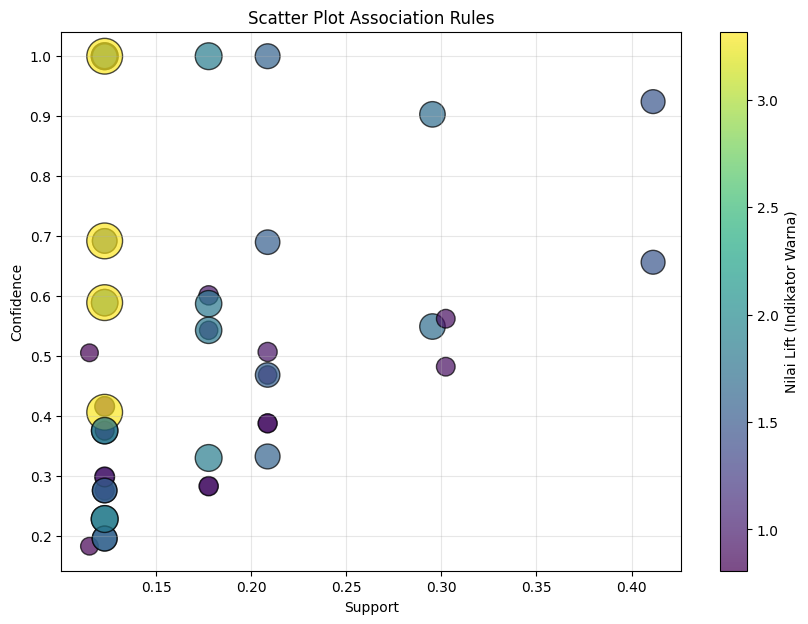

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.scatter(
    rules['support'],
    rules['confidence'],
    s=rules['lift']*200,
    c=rules['lift'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='black'
)

plt.colorbar(label='Nilai Lift (Indikator Warna)')

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Scatter Plot Association Rules")

plt.grid(alpha=0.3)

plt.show()

Network Graph

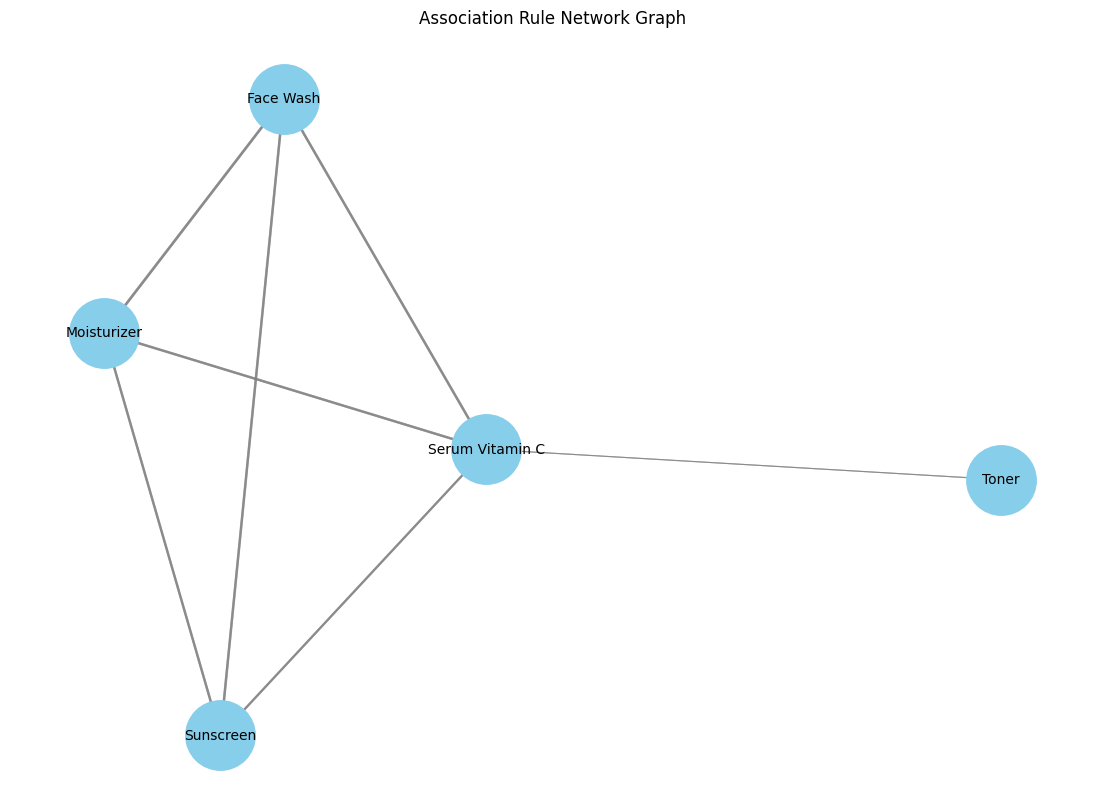

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for _, row in rules.iterrows():

    ants = list(row['antecedents'])
    cons = list(row['consequents'])

    for a in ants:
        for c in cons:
            G.add_edge(
                a,
                c,
                weight=row['lift'],
                confidence=row['confidence']
            )

plt.figure(figsize=(14,10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1
)

weights = [G[u][v]['weight'] for u,v in G.edges()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2500,
    node_color="skyblue"
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

nx.draw_networkx_edges(
    G,
    pos,
    width=weights,
    arrows=True,
    alpha=0.7,
    edge_color="gray"
)

plt.title("Association Rule Network Graph")

plt.axis("off")

plt.show()

Bubble Plot

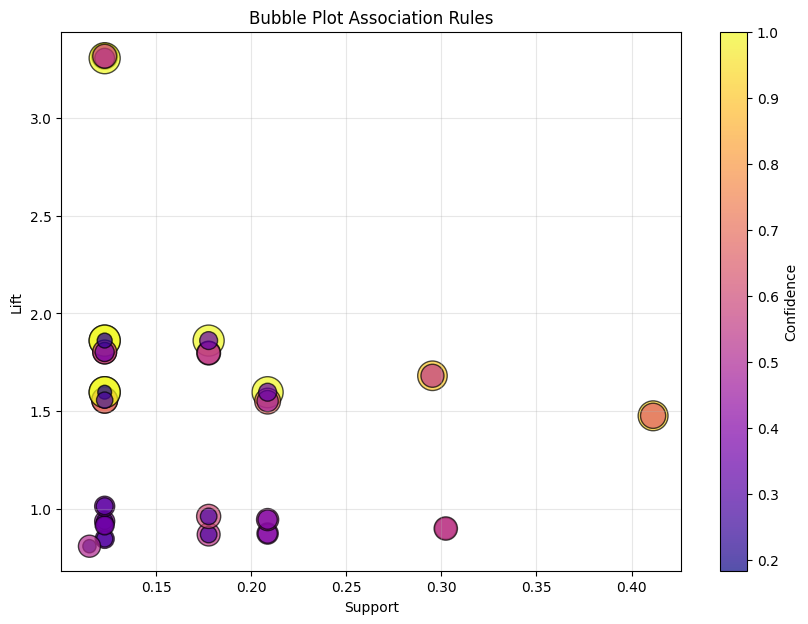

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(
    rules['support'],
    rules['lift'],
    s=rules['confidence']*500,
    c=rules['confidence'],
    cmap='plasma',
    alpha=0.7,
    edgecolors='black'
)

plt.xlabel("Support")
plt.ylabel("Lift")

plt.title("Bubble Plot Association Rules")

plt.colorbar(label="Confidence")

plt.grid(alpha=0.3)

plt.show()

Scatter Plot Cross-selling

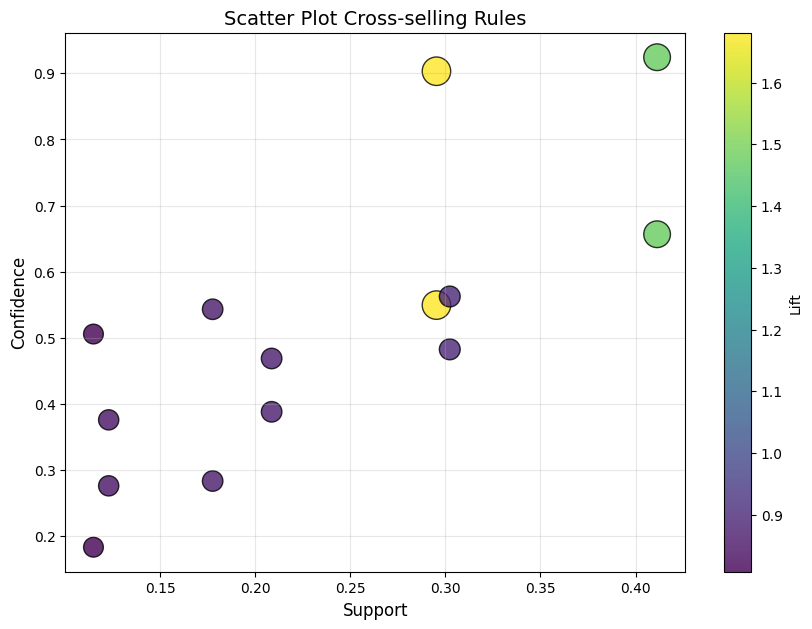

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    cross_selling_rules['support'],
    cross_selling_rules['confidence'],
    c=cross_selling_rules['lift'],
    s=cross_selling_rules['lift']*250,
    cmap='viridis',
    edgecolors='black',
    alpha=0.8
)

plt.colorbar(scatter,label='Lift')

plt.xlabel("Support",fontsize=12)
plt.ylabel("Confidence",fontsize=12)
plt.title("Scatter Plot Cross-selling Rules",fontsize=14)

plt.grid(alpha=0.3)

plt.show()

Network Graph Cross-selling

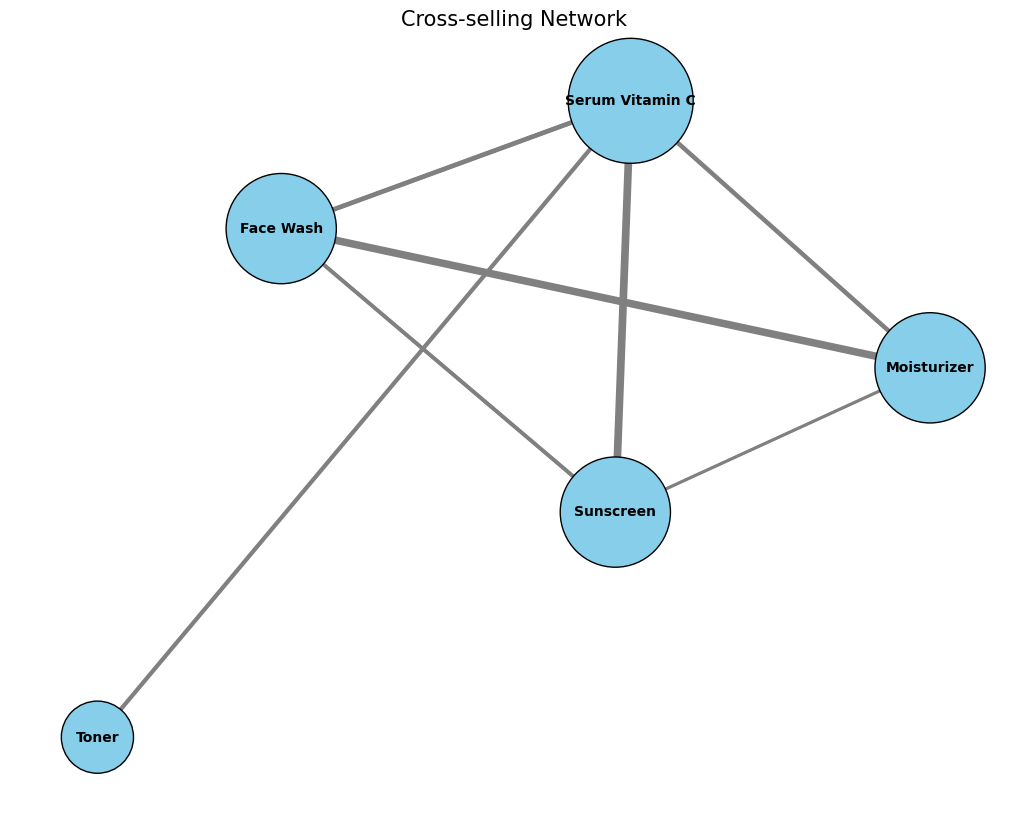

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for _, row in cross_selling_rules.iterrows():

    a = list(row['antecedents'])[0]
    c = list(row['consequents'])[0]

    G.add_edge(
        a,
        c,
        weight=row['confidence'],
        lift=row['lift']
    )

plt.figure(figsize=(13,10))

pos = nx.spring_layout(
    G,
    seed=15,
    k=1.2
)

edge_width = [
    G[u][v]['weight']*6
    for u,v in G.edges()
]

node_size = [
    G.degree(node)*900+900
    for node in G.nodes()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_size,
    node_color="#87CEEB",
    edgecolors="black"
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold"
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_width,
    arrows=True,
    arrowsize=20,
    edge_color="gray"
)

plt.title("Cross-selling Network",fontsize=15)

plt.axis("off")
plt.show()

Scatter Plot Bundling

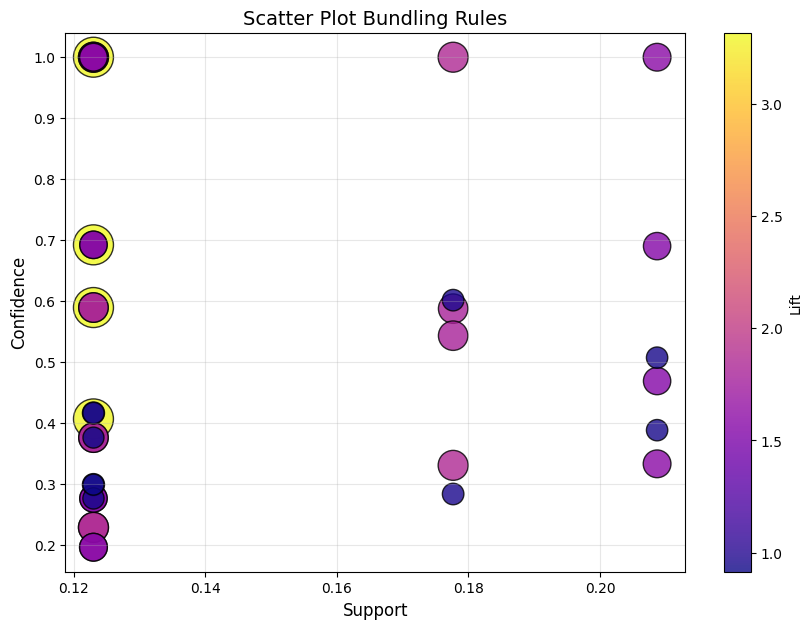

In [ ]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    bundling_rules['support'],
    bundling_rules['confidence'],
    c=bundling_rules['lift'],
    s=bundling_rules['lift']*250,
    cmap='plasma',
    edgecolors='black',
    alpha=0.8
)

plt.colorbar(scatter,label='Lift')

plt.xlabel("Support",fontsize=12)
plt.ylabel("Confidence",fontsize=12)
plt.title("Scatter Plot Bundling Rules",fontsize=14)

plt.grid(alpha=0.3)

plt.show()

Network Graph Bundling

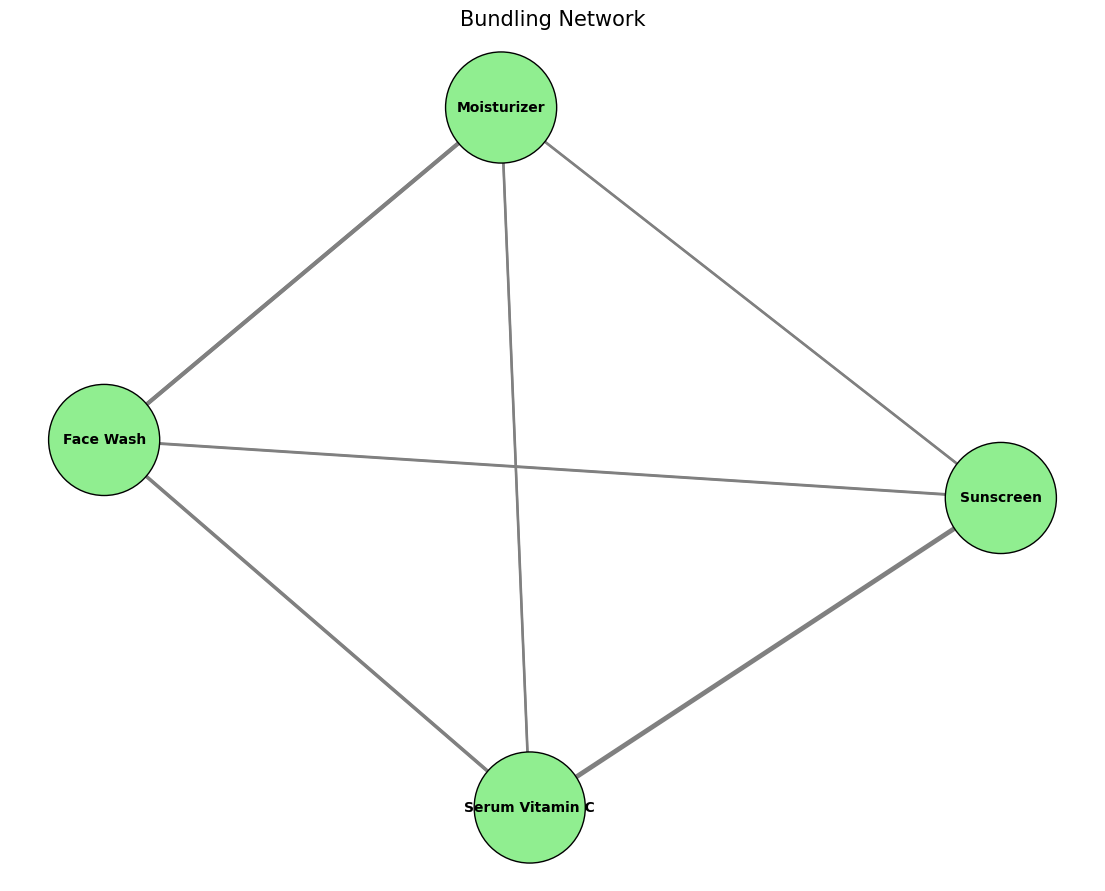

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for _, row in bundling_rules.iterrows():

    ants = list(row['antecedents'])
    cons = list(row['consequents'])

    for a in ants:
        for c in cons:

            G.add_edge(
                a,
                c,
                weight=row['confidence'],
                lift=row['lift']
            )

plt.figure(figsize=(14,11))

pos = nx.spring_layout(
    G,
    seed=20,
    k=1.5
)

edge_width = [
    G[u][v]['weight']*5
    for u,v in G.edges()
]

node_size = [
    G.degree(node)*900+1000
    for node in G.nodes()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_size,
    node_color="lightgreen",
    edgecolors="black"
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold"
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_width,
    arrows=True,
    arrowsize=20,
    edge_color="gray"
)

plt.title("Bundling Network",fontsize=15)

plt.axis("off")

plt.show()

In [ ]:
import os

# Create the 'figures' directory if it doesn't exist
if not os.path.exists('figures'):
    os.makedirs('figures')

plt.savefig('figures/scatter_plot_rules.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/execution_time_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/network_graph_cross_selling.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/network_graph_bundling.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>